# 知识图谱：光子 SNN 相干前端研究（双项目联合）

**范围**：
- 本项目 `lidar-pointnet/snn`：相参脉冲串蓄水池处理（M1–M6 + 分类上限探测 +
  ANN 上限基准 + 3D 视角扫描）
- 隔壁项目 `tfln-dispersion-lab`：TFLN 啁啾光栅 / ADC-free 光子 LiDAR
  （M1 光子链路 → M2 SNN 分类 → M3 可调延迟 → M4 ISAL 距离像）

**读法**：节点 = 器件 / 仿真器 / 方法 / 实验 / 结论 / 应用（六层，颜色区分）；
边 = 生成 / 验证 / 证伪 / 复用 / 使能 / 响应。所有数字均有实测出处（见对照表）。
数据导出 `kg_data.json`。

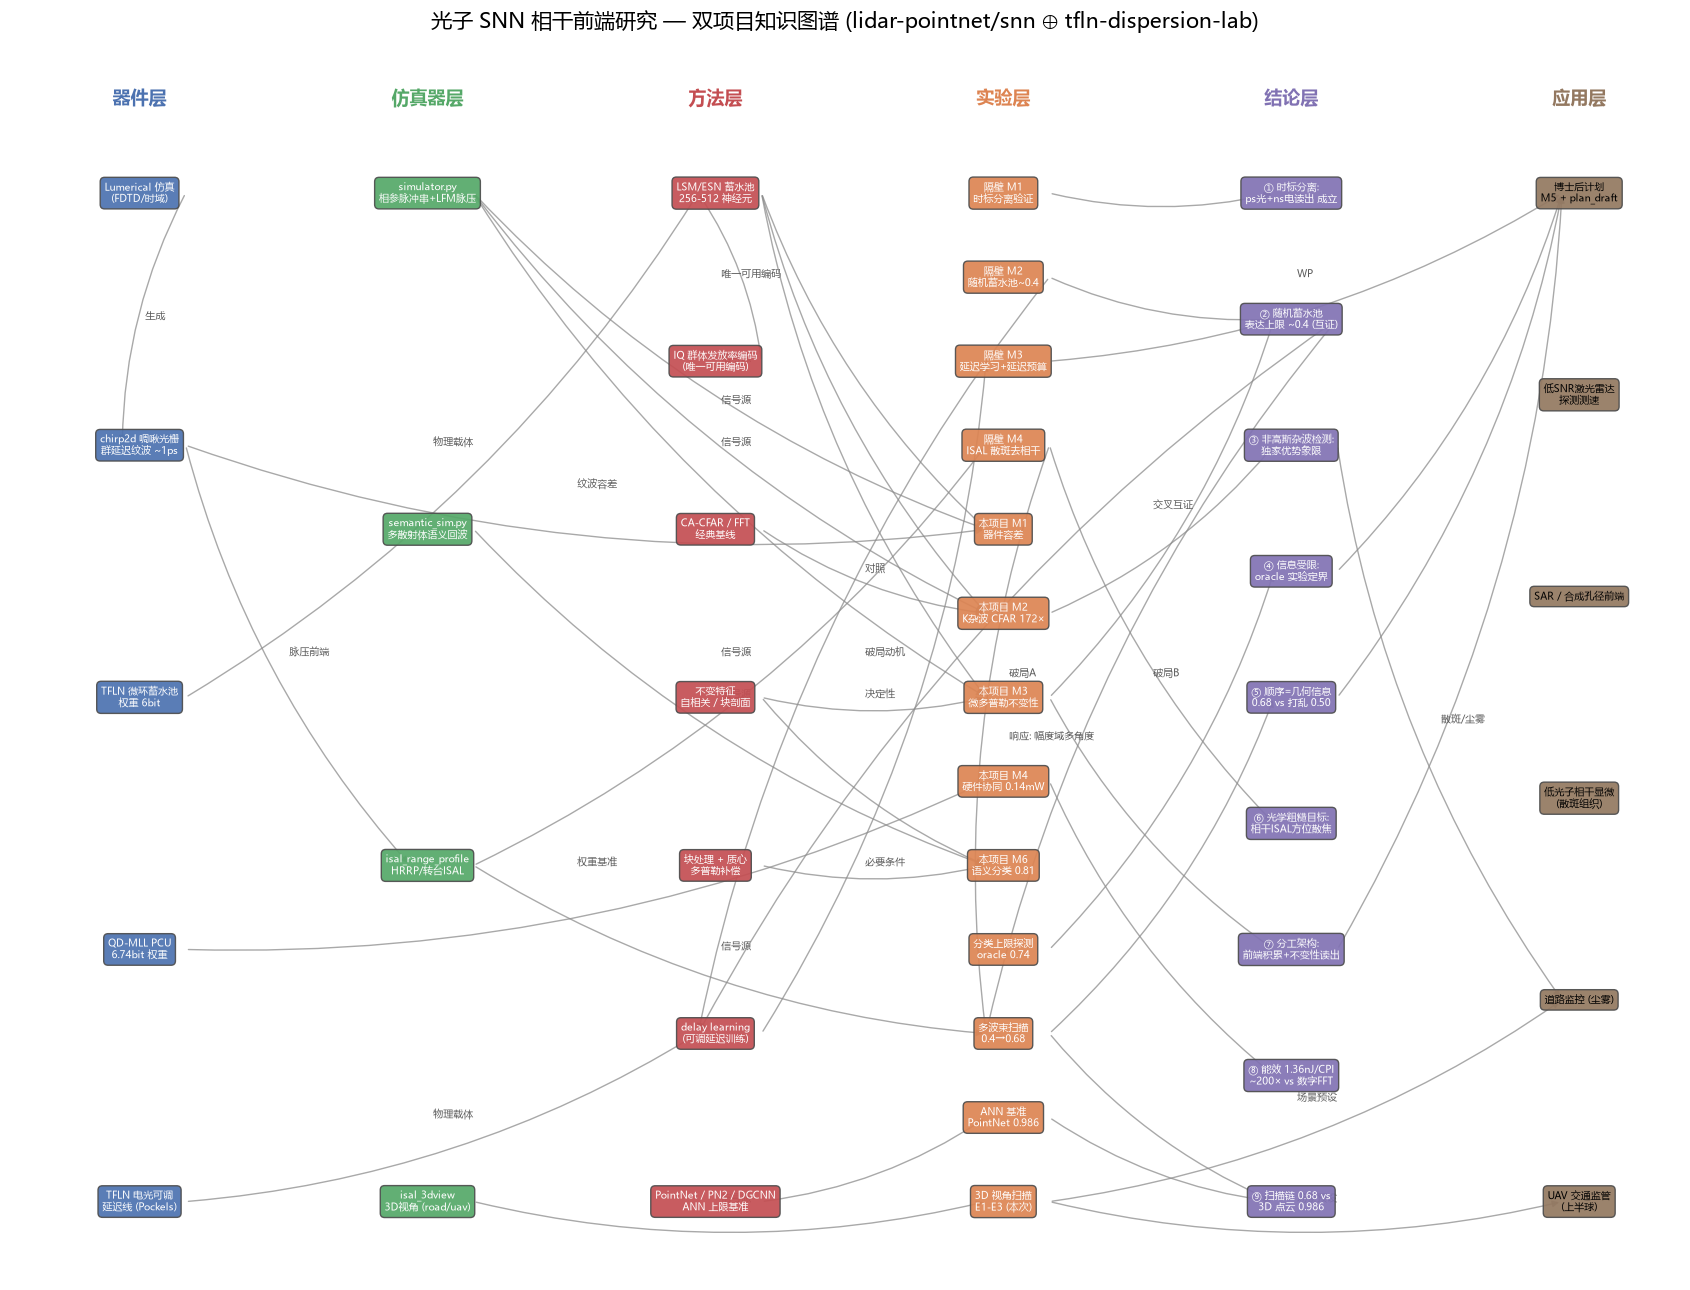

nodes=44 edges=45 -> kg_data.json


In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

COLS = ["器件层", "仿真器层", "方法层", "实验层", "结论层", "应用层"]
COLC = ["#4C72B0", "#55A868", "#C44E52", "#DD8452", "#8172B3", "#937860"]

# (id, 标签, 层)
NODES = [
    ("hw_lum",  "Lumerical 仿真\n(FDTD/时域)", 0),
    ("hw_grat", "chirp2d 啁啾光栅\n群延迟纹波 ~1ps", 0),
    ("hw_ring", "TFLN 微环蓄水池\n权重 6bit", 0),
    ("hw_qd",   "QD-MLL PCU\n6.74bit 权重", 0),
    ("hw_dly",  "TFLN 电光可调\n延迟线 (Pockels)", 0),
    ("sim_pls", "simulator.py\n相参脉冲串+LFM脉压", 1),
    ("sim_sem", "semantic_sim.py\n多散射体语义回波", 1),
    ("sim_isal","isal_range_profile\nHRRP/转台ISAL", 1),
    ("sim_3dv", "isal_3dview\n3D视角 (road/uav)", 1),
    ("m_lsm",   "LSM/ESN 蓄水池\n256-512 神经元", 2),
    ("m_enc",   "IQ 群体发放率编码\n(唯一可用编码)", 2),
    ("m_cfar",  "CA-CFAR / FFT\n经典基线", 2),
    ("m_inv",   "不变特征\n自相关 / 块剖面", 2),
    ("m_blk",   "块处理 + 质心\n多普勒补偿", 2),
    ("m_dly",   "delay learning\n(可调延迟训练)", 2),
    ("m_ann",   "PointNet / PN2 / DGCNN\nANN 上限基准", 2),
    ("t_m1", "隔壁 M1\n时标分离验证", 3),
    ("t_m2", "隔壁 M2\n随机蓄水池~0.4", 3),
    ("t_m3", "隔壁 M3\n延迟学习+延迟预算", 3),
    ("t_m4", "隔壁 M4\nISAL 散斑去相干", 3),
    ("p_m1", "本项目 M1\n器件容差", 3),
    ("p_m2", "本项目 M2\nK杂波 CFAR 172×", 3),
    ("p_m3", "本项目 M3\n微多普勒不变性", 3),
    ("p_m4", "本项目 M4\n硬件协同 0.14mW", 3),
    ("p_m6", "本项目 M6\n语义分类 0.81", 3),
    ("p_cl", "分类上限探测\noracle 0.74", 3),
    ("p_sc", "多波束扫描\n0.4→0.68", 3),
    ("p_ann","ANN 基准\nPointNet 0.986", 3),
    ("p_3d", "3D 视角扫描\nE1-E3 (本次)", 3),
    ("c_ts", "① 时标分离:\nps光+ns电读出 成立", 4),
    ("c_cap","② 随机蓄水池\n表达上限 ~0.4 (互证)", 4),
    ("c_ng", "③ 非高斯杂波检测:\n独家优势象限", 4),
    ("c_inf","④ 信息受限:\noracle 实验定界", 4),
    ("c_ord","⑤ 顺序=几何信息\n0.68 vs 打乱 0.50", 4),
    ("c_sp", "⑥ 光学粗糙目标:\n相干ISAL方位散焦", 4),
    ("c_dv", "⑦ 分工架构:\n前端积累+不变性读出", 4),
    ("c_en", "⑧ 能效 1.36nJ/CPI\n~200× vs 数字FFT", 4),
    ("c_gap","⑨ 扫描链 0.68 vs\n3D 点云 0.986", 4),
    ("a_plan","博士后计划\nM5 + plan_draft", 5),
    ("a_lid", "低SNR激光雷达\n探测测速", 5),
    ("a_sar", "SAR / 合成孔径前端", 5),
    ("a_mic", "低光子相干显微\n(散斑组织)", 5),
    ("a_rd",  "道路监控 (尘雾)", 5),
    ("a_uav", "UAV 交通监管\n(上半球)", 5),
]
EDGES = [
    ("hw_lum","hw_grat","生成"), ("hw_grat","p_m1","纹波容差"),
    ("hw_grat","sim_isal","脉压前端"), ("hw_ring","m_lsm","物理载体"),
    ("hw_qd","p_m4","权重基准"), ("hw_dly","m_dly","物理载体"),
    ("sim_pls","p_m1","信号源"), ("sim_pls","p_m2","信号源"), ("sim_pls","p_m3","信号源"),
    ("sim_sem","p_m6","信号源"), ("sim_isal","t_m4","信号源"), ("sim_isal","p_sc","信号源"),
    ("sim_3dv","p_3d","信号源"),
    ("m_enc","m_lsm","唯一可用编码"), ("m_lsm","p_m1",""), ("m_lsm","p_m2",""),
    ("m_lsm","p_m3",""), ("m_cfar","p_m2","对照"), ("m_inv","p_m3","决定性"),
    ("m_inv","p_m6",""), ("m_blk","p_m6","必要条件"), ("m_ann","p_ann",""),
    ("t_m1","c_ts",""), ("t_m2","c_cap",""), ("p_m3","c_cap","交叉互证"),
    ("t_m2","m_dly","破局动机"), ("m_dly","t_m3",""), ("t_m4","c_sp",""),
    ("t_m4","p_sc","响应: 幅度域多角度"), ("p_m2","c_ng",""), ("p_cl","c_inf",""),
    ("p_m3","c_dv",""), ("p_m4","c_en",""), ("p_sc","c_ord",""),
    ("p_ann","c_gap",""), ("p_sc","c_gap",""), ("p_3d","a_rd","场景预设"),
    ("p_3d","a_uav","场景预设"), ("c_cap","m_dly","破局A"), ("c_cap","p_sc","破局B"),
    ("c_dv","a_plan",""), ("c_ng","a_rd","散斑/尘雾"), ("t_m3","a_plan","WP"),
    ("c_inf","a_plan",""), ("c_ord","a_plan",""),
]
idx = {n[0]: i for i, n in enumerate(NODES)}
# 自动布局: 层内均分 y
pos = {}
per_col = {}
for nid, lab, col in NODES:
    per_col.setdefault(col, []).append(nid)
for col, ids in per_col.items():
    ys = np.linspace(0.95, 0.05, len(ids))
    for nid, y in zip(ids, ys):
        pos[nid] = (col * 1.0, y)

fig, ax = plt.subplots(figsize=(17, 13))
for s, d, rel in EDGES:
    x0, y0 = pos[s]; x1, y1 = pos[d]
    ax.annotate("", xy=(x1 - 0.06, y1), xytext=(x0 + 0.16, y0),
                arrowprops=dict(arrowstyle="-|>", color="0.55", lw=1.0, alpha=0.75,
                                connectionstyle="arc3,rad=0.12"))
    if rel:
        xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
        ax.text(xm + 0.02, ym, rel, fontsize=7, color="0.35", style="italic")
for nid, lab, col in NODES:
    x, y = pos[nid]
    ax.text(x, y, lab, fontsize=7.5, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.42", fc=COLC[col], ec="0.3", alpha=0.92),
            color="w" if col != 5 else "k")
for c in range(6):
    ax.text(c, 1.03, COLS[c], fontsize=13, ha="center", fontweight="bold",
            color=COLC[c])
ax.set_xlim(-0.45, 5.35); ax.set_ylim(-0.02, 1.08); ax.axis("off")
ax.set_title("光子 SNN 相干前端研究 — 双项目知识图谱 (lidar-pointnet/snn ⊕ tfln-dispersion-lab)",
             fontsize=15, pad=14)
plt.tight_layout(); plt.show()

json.dump({"nodes": [{"id": n, "label": l, "layer": COLS[c]} for n, l, c in NODES],
           "edges": [{"src": s, "dst": d, "relation": r} for s, d, r in EDGES]},
          open(Path("kg_data.json"), "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)
print("nodes=%d edges=%d -> kg_data.json" % (len(NODES), len(EDGES)))

## 图 2 · 证据链子图：两条破局路径如何汇聚

**起点（跨项目互证）**：固定随机蓄水池在复杂 3D 任务上饱和在 ~0.35–0.42
（隔壁 M2 与我们的 ModelNet40 demo 独立复现同一数字）→ 它逼出两条破局路径：

- **路径 A（器件侧）**：把固定延迟抽头换成 TFLN 电光可调延迟（Pockels），
  用 delay learning 训练——隔壁 M3 定量回答"可调延迟值多少钱 + ns 级延迟在
  TFLN 上是否可行"，是计划书的原创性核心；
- **路径 B（传感侧）**：不再指望单次投影，用已知角度的有序多波束扫描把几何
  信息写进时序——0.4→0.68，打乱顺序跌回 0.50 证明顺序本身就是信息。
  它同时是对隔壁 M4"第三面墙"（相干 ISAL 被散斑去相干摧毁）的直接回应：
  放弃方位相干，走幅度域多角度。

**汇聚**：两条路径在"信息受限 + 分工架构"这一结论层汇合——蓄水池的价值
边界在传感几何与噪声统计决定的信息前沿，而非表达力；器件的任务是以 µW 功耗
把前沿推得更远。

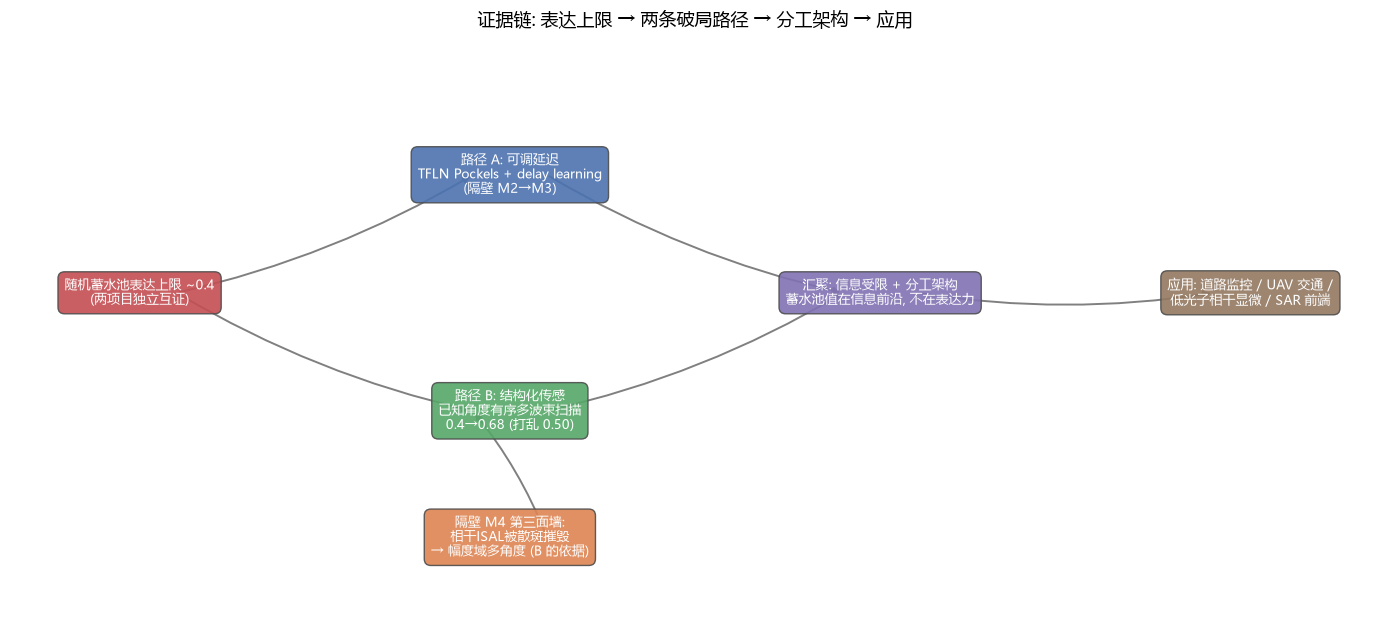

In [2]:
fig, ax = plt.subplots(figsize=(14, 6.5))
story = [
    ("随机蓄水池表达上限 ~0.4\n(两项目独立互证)", 0, 0.5, "#C44E52"),
    ("路径 A: 可调延迟\nTFLN Pockels + delay learning\n(隔壁 M2→M3)", 1, 0.78, "#4C72B0"),
    ("路径 B: 结构化传感\n已知角度有序多波束扫描\n0.4→0.68 (打乱 0.50)", 1, 0.22, "#55A868"),
    ("隔壁 M4 第三面墙:\n相干ISAL被散斑摧毁\n→ 幅度域多角度 (B 的依据)", 1, -0.08, "#DD8452"),
    ("汇聚: 信息受限 + 分工架构\n蓄水池值在信息前沿, 不在表达力", 2, 0.5, "#8172B3"),
    ("应用: 道路监控 / UAV 交通 /\n低光子相干显微 / SAR 前端", 3, 0.5, "#937860"),
]
links = [(0, 1), (0, 2), (3, 2), (1, 4), (2, 4), (4, 5)]
for a, b in links:
    x0, y0 = story[a][1], story[a][2]; x1, y1 = story[b][1], story[b][2]
    ax.annotate("", xy=(x1 - 0.10, y1), xytext=(x0 + 0.10, y0),
                arrowprops=dict(arrowstyle="-|>", color="0.5", lw=1.4,
                                connectionstyle="arc3,rad=0.08"))
for lab, x, y, c in story:
    ax.text(x, y, lab, fontsize=9.5, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.5", fc=c, ec="0.3", alpha=0.9), color="w")
ax.set_xlim(-0.35, 3.35); ax.set_ylim(-0.3, 1.1); ax.axis("off")
ax.set_title("证据链: 表达上限 → 两条破局路径 → 分工架构 → 应用", fontsize=13, pad=10)
plt.tight_layout(); plt.show()

## 双项目里程碑对照表（实测数字与出处）

### 隔壁项目 `tfln-dispersion-lab`（ADC-free 光子 LiDAR）

| 里程碑 | 核心数字/结论 | 出处 |
|---|---|---|
| M1 光子链路 | 读出延迟 ≈ τ_leak 前准确率 ~1.0；τ_leak=5ns 时读出窗口 >10ns；**ps 光处理 + ns 电读出的时标分离成立** | milestone-M1-photonic-chain.ipynb |
| M2 SNN 分类 | digits 94%；复杂 3D 任务随机蓄水池饱和 0.35–0.42（与我们的 ModelNet demo 互证）→ 提出可调延迟破局 | milestone-M2-snn-classification.ipynb |
| M3 可调延迟 | delay learning 的价值边界 + TFLN 上 ns 级延迟物理预算 | milestone-M3-delay-learning-and-budget.ipynb |
| M4 ISAL | ±3° 相干孔径转台 ISAL：θ_c=∞ 轮廓清晰；θ_c=0.3° 散焦；0.05° 消失——**光学粗糙目标相干 ISAL 被自身散斑摧毁**（第三面墙） | milestone-M4-isal-range-profile.ipynb |
| 器件 | chirp2d 啁啾光栅群延迟纹波 RMS ~1ps；QD-MLL PCU 权重 6.74 bit | lumerical/results/chirp2d.npz |

### 本项目 `lidar-pointnet/snn`（相参脉冲串蓄水池）

| 里程碑 | 核心数字 | 出处 |
|---|---|---|
| M1 器件容差 | 纹波 ~1ps / leak 失配 2–20% / 6bit 量化：性能无损 | notebooks/m1 |
| M2 非高斯杂波 | CFAR 虚警膨胀 **172×** 全失效；LSM 保持 0.2–0.3，低 CNR 优于 oracle CFAR-K | notebooks/m2 |
| M3 微多普勒 | 不变性决定分类：自相关+线性 0.71@+5dB；池状态+二次核 0.25 | notebooks/m3 |
| 上限探测 | oracle 去载波也只 0.74@+5dB → **信息受限** | cls_ceiling.log |
| M4 硬件协同 | 4.3×10⁴ ops/CPI、1.36nJ/CPI、0.14mW@100kHz（~200× vs 数字 FFT） | notebooks/m4 |
| M6 语义分类 | 块+补偿链：0.79–0.81 @+5dB；v1 单门 0.26（阴性对照） | notebooks/m6 |
| 多波束扫描 | 单次 0.36–0.42 → 4 波束×3 步+ESN **0.68**；打乱 0.50 | isal_beam_scan.log |
| ANN 上限 | 裸 PointNet（CPU 15ep，256 点）**0.986** | ann_bench_cpu_sanity |
| 3D 视角扫描 | road_crossing / uav_cap 预设 + 跨分布 + 俯仰维标价（本笔记本下方引用） | outputs_isal/3dview |

### 交叉引用关系（两个项目如何咬合）

1. **chirp2d 光栅**（隔壁生成）→ 本项目 M1 做纹波容差验证 + ISAL 脉压前端；
2. **随机蓄水池上限 ~0.4**（隔壁 M2 提出，本项目 demo 独立复现）→ 共同动机；
3. **第三面墙**（隔壁 M4）→ 多波束幅度域扫描（本项目）是对它的直接回应；
4. **delay learning**（隔壁 M3）+ 本项目检测/扫描结论 → 共同进入博士后计划 WP；
5. **postdoc_plan_draft.md**（隔壁）与 M5 笔记本（本项目）互为草稿。

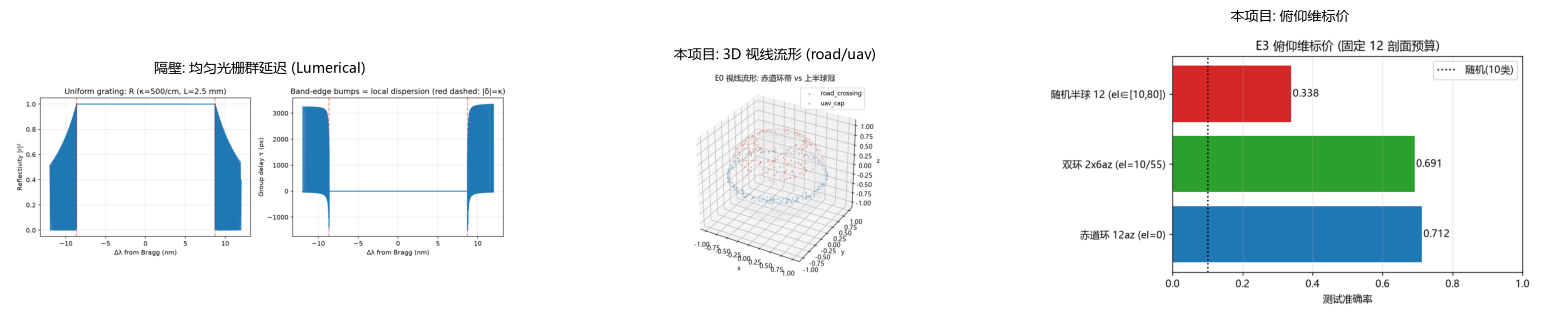

In [3]:
import matplotlib.image as mpimg
figs = [(r"D:\kimi_workspace\tfln-dispersion-lab\results\2026-09-18-uniform-grating-gd.png",
         "隔壁: 均匀光栅群延迟 (Lumerical)"),
        (str(Path(r"D:\kimi_workspace\lidar-pointnet\snn\outputs_isal\3dview\e0_view_manifolds.png")),
         "本项目: 3D 视线流形 (road/uav)"),
        (str(Path(r"D:\kimi_workspace\lidar-pointnet\snn\outputs_isal\3dview\e3_elevation_price.png")),
         "本项目: 俯仰维标价")]
avail = [(p, t) for p, t in figs if Path(p).exists()]
if avail:
    fig, axes = plt.subplots(1, len(avail), figsize=(5.2 * len(avail), 4))
    if len(avail) == 1:
        axes = [axes]
    for ax, (p, t) in zip(axes, avail):
        ax.imshow(mpimg.imread(p)); ax.set_title(t, fontsize=10); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("(图文件尚不存在 — 先运行 isal_3dview.py)")

## 生长方式

新增实验/结论时：在第一个代码格的 `NODES` / `EDGES` 里追加条目（层归属决定颜色与
布局），重跑本笔记本并同步更新对照表。`kg_data.json` 为机器可读版本，
可供 Obsidian vault（`Heterogeneous_integration`）或后续论文图复用。